# NB2 - Preprocessing des images de factures

Ce notebook reste volontairement centré sur le preprocessing "page entière".

L'EDA a montré que les lignes peuvent avoir des ratios largeur / hauteur très élevés. Ici, on normalise la page complète pour stabiliser la détection des zones de texte avant la reconnaissance.

Les spécificités de préparation propres au module REC sont précisées ensuite dans NB3.


## 0. Imports et chemins

**Imports**

`skimage.metrics.structural_similarity` (SSIM) : métrique de qualité d'image qui mesure la similarité structurelle entre deux images ([-1, 1], 1=identique).

Utilisée ici pour prouver que le pipeline de preprocessing ne détruit pas l'information utile du document.

**Échantillonnage**

`rng = np.random.default_rng(42)` : seed fixe = résultats reproductibles.

Si le batch contient plus de 30 images, on tire 30 au hasard pour garder l'évaluation rapide tout en étant représentative.

### Imports

In [4]:
import sys
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 110

### Recherche de la racine du projet, chemins du dataset et échantillonnage reproductible

In [5]:
def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "Promy_raw").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


PROJECT_ROOT = find_project_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
DATASET_ROOT = PROJECT_ROOT / "Promy_raw" / "datasets" / "High-Quality Invoice Images for OCR"
BATCH1_DIR = DATASET_ROOT / "batch_1" / "batch_1"

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))


def list_image_paths(batch_dir):
    paths = []
    for subdir in sorted([p for p in batch_dir.iterdir() if p.is_dir()]):
        paths.extend(sorted([p for p in subdir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]))
    return paths


**Échantillonnage reproductible : 30 images tirées aléatoirement.**

In [6]:
rng = np.random.default_rng(42)
all_paths = list_image_paths(BATCH1_DIR)
sample_paths = all_paths if len(all_paths) <= 30 else list(rng.choice(all_paths, size=30, replace=False))
sample_paths = sorted(sample_paths, key=lambda p: p.name)

print(f"{len(sample_paths)} images sélectionnées pour l'évaluation du preprocessing")

30 images sélectionnées pour l'évaluation du preprocessing


## 1. Construction du pipeline

### Fonctions partagées

Les fonctions de preprocessing sont définies dans `preprocessing.py` et importées ici.

Ce module est la **source unique** partagée par les composants du projet qui ont besoin d'appliquer explicitement ces transformations côté application : préparation des données pour l'analyse, démonstrateur Gradio, déploiement sur Hugging Face Spaces.

Chaque étape : grayscale LAB => resize 2480 px => CLAHE => deskew => denoise.

Note : dans NB3, l'entraînement PaddleOCR REC consomme les images via sa propre chaîne de normalisation interne (redimensionnement 32×100, normalisation CTC) ; le module est importé dans NB3 au niveau des analyses qualitatives et de l'inférence applicative, là où l'utilisateur manipule directement les images avant de les soumettre au modèle.

On l'importe ci-dessous pour garantir que tous les supports utilisent exactement la même version du pipeline.

In [7]:
import importlib
import preprocessing
from preprocessing import (
    to_grayscale_lab,
    resize_to_width,
    apply_clahe,
    deskew,
    denoise,
    preprocess_invoice,
)

print("Fonctions importées depuis preprocessing.py")

Fonctions importées depuis preprocessing.py


## 2. Démonstration du pipeline complet

Démonstration sur la première image de l'échantillon.

`preprocess_invoice()` applique le pipeline complet et renvoie :
- l'image traitée (numpy array uint8 niveaux de gris)
- metadata : taille originale, taille finale, angle de deskew détecté

L'angle de deskew est le premier indicateur utile : s'il est systématiquement élevé (> 2°), cela révèle un problème de numérisation dans le dataset.

In [8]:
demo_path = sample_paths[0]
demo_gray, demo_meta = preprocess_invoice(demo_path)
print(f"Image de démonstration : {demo_path.name}")
print(f"Taille originale      : {demo_meta['original_size']}")
print(f"Taille preprocessée   : {demo_meta['processed_size']}")
print(f"Angle deskew          : {demo_meta['deskew_angle']:.2f}°")

Image de démonstration : batch1-0126.jpg
Taille originale      : (1654, 2339)
Taille preprocessée   : (2480, 3507)
Angle deskew          : 0.00°


## 3. Mesure SSIM (Structural Similarity)

Le SSIM (Structural Similarity) compare l'image d'origine en niveaux de gris et l'image préprocessée à taille identique.

Une valeur très élevée signifie ici que le pipeline normalise sans détruire la structure utile du document.

### Grille avant/après sur 6 images avec mesure SSIM individuelle.

Pour comparer justement, l'image originale en niveaux de gris est redimensionnée à la même taille que l'image preprocessée (SSIM exige des dimensions identiques).

Un SSIM proche de 1.0 signifie que le preprocessing n'a pas altéré la structure.

**C'est une donnée clé : les images Kaggle sont déjà propres, le preprocessing joue un rôle de NORMALISATION (résolution uniforme, contraste stable) et non de correction d'un dataset dégradé.**

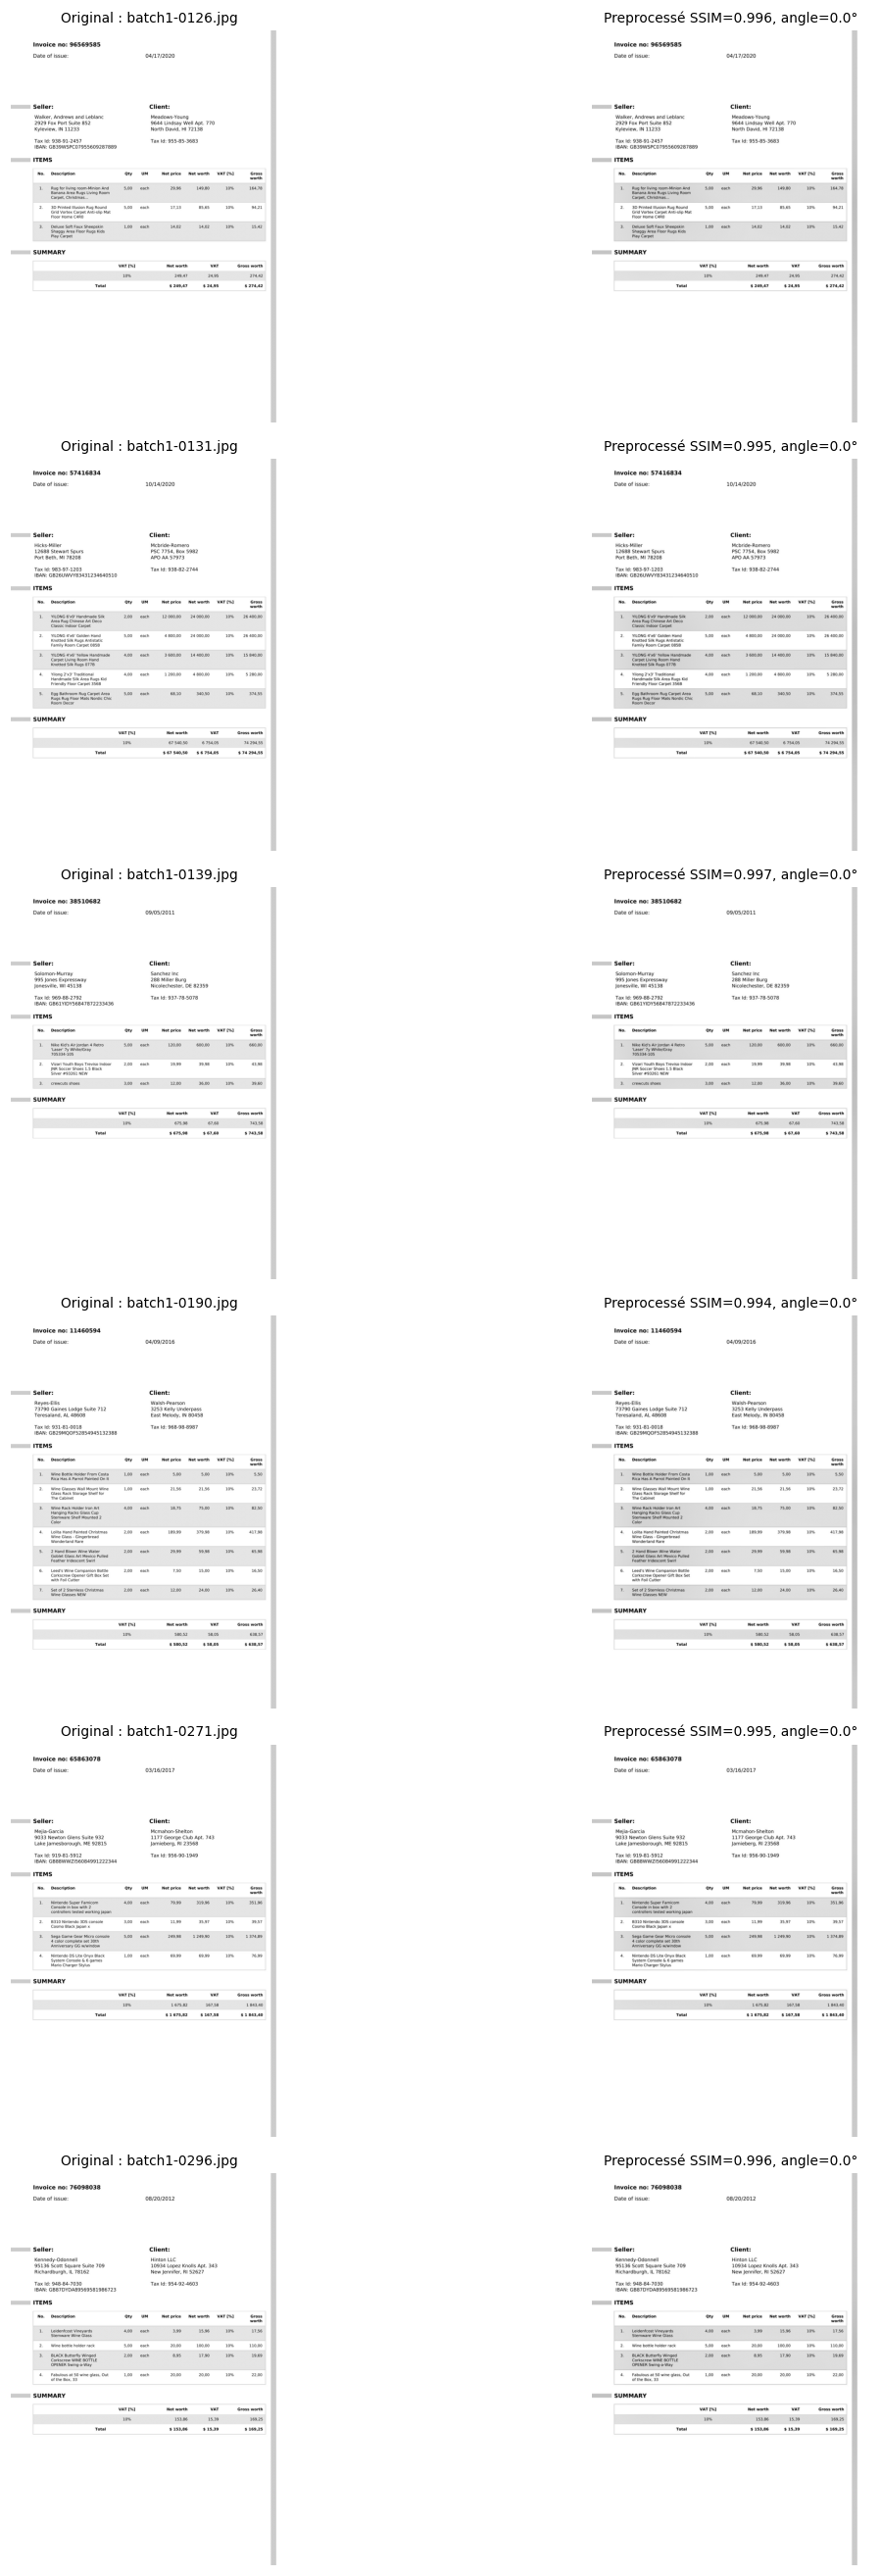

SSIM moyen sur les 6 images affichées : 0.996


In [6]:
display_paths = sample_paths[:6]

fig, axes = plt.subplots(len(display_paths), 2, figsize=(14, 4 * len(display_paths)))
if len(display_paths) == 1:
    axes = np.array([axes])

ssim_scores = []
for i, path in enumerate(display_paths):
    img_bgr = cv2.imread(str(path))
    original_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    processed, meta = preprocess_invoice(path)
    original_resized = cv2.resize(original_gray, (processed.shape[1], processed.shape[0]))
    score = ssim(original_resized, processed)
    ssim_scores.append(score)

    axes[i, 0].imshow(original_gray, cmap="gray")
    axes[i, 0].set_title(f"Original : {path.name}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(processed, cmap="gray")
    axes[i, 1].set_title(f"Preprocessé SSIM={score:.3f}, angle={meta['deskew_angle']:.1f}°", fontsize=9)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()
print(f"SSIM moyen sur les 6 images affichées : {np.mean(ssim_scores):.3f}")

Avec un SSIM moyen de 0.996, la conclusion est que les images du dataset sont déjà de bonne qualité.
Le preprocessing ne corrige pas un dataset dégradé.
Il joue un rôle de normalisation préventive et de stabilisation. Le score élevé confirme surtout l'absence d'artefacts destructifs introduits par le pipeline.

## 4. Mesure d'impact sur les 30 images échantillonnées

Mesure systématique sur les 30 images de l'échantillon.

Métriques collectées pour chaque image :
- ***ssim***            : fidélité de l'image preprocessée vs originale
- ***deskew_angle***    : angle de correction appliqué (abs → peu importe le sens)
- ***contrast_before*** : écart-type des niveaux de gris avant CLAHE
- ***contrast_after***  : écart-type des niveaux de gris après CLAHE
- ***contrast_gain***   : différence after - before (peut être négatif, voir note dans la lecture ci-dessous)

Les 3 histogrammes résument visuellement l'impact du pipeline sur l'ensemble du dataset.

In [7]:
results = []
for path in sample_paths:
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        continue
    original_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    contrast_before = float(original_gray.std())
    processed, meta = preprocess_invoice(path)
    contrast_after = float(processed.std())
    original_resized = cv2.resize(original_gray, (processed.shape[1], processed.shape[0]))
    score = ssim(original_resized, processed)
    results.append(
        {
            "filename": path.name,
            "ssim": score,
            "deskew_angle": meta["deskew_angle"],
            "contrast_before": contrast_before,
            "contrast_after": contrast_after,
            "contrast_gain": contrast_after - contrast_before,
        }
    )

df_results = pd.DataFrame(results)
print(df_results.describe().round(3).to_string())


         ssim  deskew_angle  contrast_before  contrast_after  contrast_gain
count  30.000          30.0           30.000          30.000         30.000
mean    0.996           0.0           31.308          30.502         -0.806
std     0.001           0.0            2.445           2.482          0.096
min     0.993           0.0           26.643          25.793         -1.041
25%     0.995           0.0           29.288          28.524         -0.870
50%     0.996           0.0           31.845          31.026         -0.803
75%     0.997           0.0           33.185          32.481         -0.734
max     0.998           0.0           36.027          35.226         -0.636


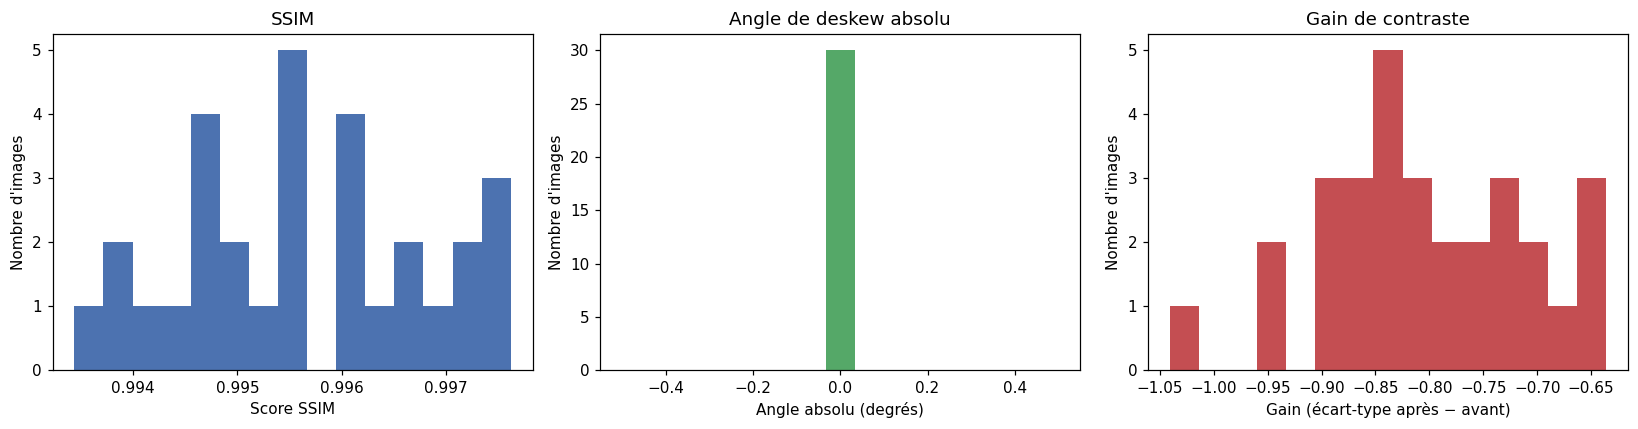

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_results["ssim"], bins=15, color="#4C72B0")
axes[0].set_title("SSIM")
axes[0].set_xlabel("Score SSIM")
axes[0].set_ylabel("Nombre d'images")
axes[1].hist(df_results["deskew_angle"].abs(), bins=15, color="#55A868")
axes[1].set_title("Angle de deskew absolu")
axes[1].set_xlabel("Angle absolu (degrés)")
axes[1].set_ylabel("Nombre d'images")
axes[2].hist(df_results["contrast_gain"], bins=15, color="#C44E52")
axes[2].set_title("Gain de contraste")
axes[2].set_xlabel("Gain (écart-type après − avant)")
axes[2].set_ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

Le SSIM reste systématiquement proche de 0.996, ce qui confirme que le pipeline ne détruit pas la structure de l'image.

Angle de deskew à 0° sur l'ensemble des 30 images = le dataset Kaggle est composé d'images déjà bien alignées. L'étape de deskew est conservée dans le pipeline partagé par précaution de robustesse pour des images hors corpus (scans inclinés, photos mobiles) où une inclinaison réelle peut exister.

Le gain de contraste (contrast_gain) est légèrement négatif en moyenne. CLAHE redistribue le contraste localement en écrêtant les amplifications excessives via le paramètre `clip_limit`. Cet écrêtage peut réduire l'écart-type global tout en améliorant la lisibilité locale. Ce qui valide CLAHE ici n'est pas l'écart-type global (mesure de dispersion d'intensité globale) mais le SSIM à 0.996, qui mesure la préservation de la structure de l'image. Le SSIM est la métrique appropriée pour valider qu'un rehaussement local n'a pas dégradé la lisibilité globale.

## 5. Module partagé


Rechargement du module pour s'assurer que la version sur disque est bien chargée.

importlib.reload() force Python à relire preprocessing.py même s'il était déjà importé dans la session.

==> utile en développement itératif.

On vérifie ensuite que les fonctions clés sont bien accessibles et fonctionnelles.

In [9]:
preprocessing = importlib.reload(preprocessing)
shared_functions = [name for name in dir(preprocessing) if not name.startswith("_")]
print("Module partagé rechargé")
print(shared_functions)

shared_gray, shared_meta = preprocessing.preprocess_invoice(sample_paths[0])
print(f"Taille de sortie (module) : {shared_gray.shape}")
print(f"Angle deskew (module)     : {shared_meta['deskew_angle']:.2f}°")

Module partagé rechargé
['Image', 'Path', 'apply_clahe', 'crop_to_padded_square', 'cv2', 'denoise', 'deskew', 'extract_text_line_crops', 'np', 'preprocess_invoice', 'resize_to_width', 'to_grayscale_lab']


Taille de sortie (module) : (3507, 2480)
Angle deskew (module)     : 0.00°


## 6. Conclusion

- le pipeline reste léger car le dataset est déjà propre
- le SSIM très élevé confirme une normalisation non destructive
- ce preprocessing stabilise la facture avant la détection des zones de texte
- les images prétraitées servent d'entrée au pipeline OCR documenté dans NB3
